# Problem Statement


In [4271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
from scipy.stats import pearsonr
from scipy.stats import f_oneway
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score




In [4272]:
df = pd.read_csv("/Users/srisuphachawla/Documents/DataScience_Projects/SupplyChain/logistics_shipments_dataset.csv")
df

,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
0,SH10000,Warehouse_MIA,San Francisco,UPS,2023-10-02,2023-10-04,25.7,67.46,Delivered,291,2
1,SH10001,Warehouse_MIA,Atlanta,DHL,2023-12-06,2023-12-09,38.9,268.85,Delivered,1225,3
2,SH10002,Warehouse_LA,Houston,DHL,2023-09-18,2023-09-20,37.2,74.35,Delivered,220,2
3,SH10003,Warehouse_BOS,Seattle,OnTrac,2023-01-26,2023-02-04,42.6,187.04,Delivered,1156,9
4,SH10004,Warehouse_SF,Dallas,OnTrac,2023-06-03,2023-06-06,7.9,120.01,Delivered,1017,3
...,...,...,...,...,...,...,...,...,...,...,...
1995,SH11995,Warehouse_BOS,San Francisco,FedEx,2023-01-18,2023-01-23,7.9,217.78,Delivered,1616,5
1996,SH11996,Warehouse_HOU,Phoenix,UPS,2023-10-27,2023-11-01,36.5,279.47,Delivered,1708,5
1997,SH11997,Warehouse_HOU,Portland,LaserShip,2023-02-13,2023-02-19,11.4,250.32,Delivered,1912,6
1998,SH11998,Warehouse_SEA,Detroit,USPS,2023-10-17,2023-10-22,10.9,272.31,Delivered,2188,5


In [4273]:
# SKU is the identifier, make it into index
df.set_index("Shipment_ID", inplace = True)

# Dataset Overview

In [4274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, SH10000 to SH11999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Origin_Warehouse  2000 non-null   object 
 1   Destination       2000 non-null   object 
 2   Carrier           2000 non-null   object 
 3   Shipment_Date     2000 non-null   object 
 4   Delivery_Date     1968 non-null   object 
 5   Weight_kg         2000 non-null   float64
 6   Cost              1959 non-null   float64
 7   Status            2000 non-null   object 
 8   Distance_miles    2000 non-null   int64  
 9   Transit_Days      2000 non-null   int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 171.9+ KB


In [4275]:
df.isnull().sum()

Origin_Warehouse     0
Destination          0
Carrier              0
Shipment_Date        0
Delivery_Date       32
Weight_kg            0
Cost                41
Status               0
Distance_miles       0
Transit_Days         0
dtype: int64

In [4276]:
df[df['Delivery_Date'].isna()].head()

,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
Shipment_ID,,,,,,,,,,
SH10030,Warehouse_SF,San Francisco,LaserShip,2023-11-04,NaN,28.5,109.33,Delivered,502,2
SH10039,Warehouse_MIA,New York,LaserShip,2023-12-08,NaN,65.2,284.81,Delivered,1204,3
SH10097,Warehouse_MIA,Atlanta,Amazon Logistics,2023-09-19,NaN,80.4,259.98,Delivered,1554,5
SH10109,Warehouse_DEN,Phoenix,LaserShip,2023-12-13,NaN,16.5,73.12,Delivered,371,2
SH10132,Warehouse_DEN,San Francisco,DHL,2023-07-07,NaN,8.4,NaN,Delivered,815,3


32 values of the Delivery dates are NaN. We can fill these up by adding Shipment_date and Transit_date

In [4277]:
df['Shipment_Date'] = pd.to_datetime(df['Shipment_Date'])

df['Delivery_Date'] = (
    df['Shipment_Date'] + pd.to_timedelta(df["Transit_Days"], unit="D")
)

In [4278]:
# done
df.loc["SH10132"] 

Origin_Warehouse          Warehouse_DEN
Destination               San Francisco
Carrier                             DHL
Shipment_Date       2023-07-07 00:00:00
Delivery_Date       2023-07-10 00:00:00
Weight_kg                           8.4
Cost                                NaN
Status                        Delivered
Distance_miles                      815
Transit_Days                          3
Name: SH10132, dtype: object

In [4279]:
df[df['Delivery_Date'].isna()].head()
# no nan values left for Delivary Date

,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
Shipment_ID,,,,,,,,,,


In [4280]:
df[df['Cost'].isna()].head()


,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
Shipment_ID,,,,,,,,,,
SH10071,Warehouse_CHI,Seattle,OnTrac,2023-06-20,2023-06-25,30.7,NaN,Delivered,2307,5
SH10101,Warehouse_DEN,Miami,LaserShip,2023-08-28,2023-08-30,51.0,NaN,Delivered,179,2
SH10132,Warehouse_DEN,San Francisco,DHL,2023-07-07,2023-07-10,8.4,NaN,Delivered,815,3
SH10146,Warehouse_BOS,Portland,USPS,2023-08-12,2023-08-17,23.7,NaN,Delivered,1459,5
SH10183,Warehouse_HOU,Dallas,Amazon Logistics,2023-09-24,2023-09-29,7.1,NaN,Delayed,1376,5


In [4281]:
## imputing the cost value 
df["Cost"] = df["Cost"].fillna(
    df["Cost"].median()
)

In [4282]:
df[df['Cost'].isna()].head()

,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
Shipment_ID,,,,,,,,,,


In [4283]:
df.loc["SH10132"] 

Origin_Warehouse          Warehouse_DEN
Destination               San Francisco
Carrier                             DHL
Shipment_Date       2023-07-07 00:00:00
Delivery_Date       2023-07-10 00:00:00
Weight_kg                           8.4
Cost                             196.42
Status                        Delivered
Distance_miles                      815
Transit_Days                          3
Name: SH10132, dtype: object

In [4284]:
df.describe()

,Shipment_Date,Delivery_Date,Weight_kg,Cost,Distance_miles,Transit_Days
count,2000,2000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2023-07-05 12:00:00,2023-07-09 16:22:48,30.184800,204.982395,1275.868000,4.182500
min,2023-01-01 00:00:00,2023-01-03 00:00:00,0.000000,17.890000,101.000000,1.000000
25%,2023-04-05 18:00:00,2023-04-11 00:00:00,12.300000,119.220000,690.250000,3.000000
50%,2023-07-07 00:00:00,2023-07-11 00:00:00,20.700000,196.420000,1262.500000,4.000000
75%,2023-10-04 00:00:00,2023-10-08 00:00:00,33.925000,271.450000,1867.250000,5.000000
max,2023-12-31 00:00:00,2024-01-08 00:00:00,5404.200000,6562.210000,2499.000000,12.000000
std,NaN,NaN,124.967053,220.295092,691.382829,1.837902


In [4285]:
df.duplicated().sum()

np.int64(0)

# Summary Statistics

In [4286]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Shipment_Date,2000,2023-07-05 12:00:00,2023-01-01 00:00:00,2023-04-05 18:00:00,2023-07-07 00:00:00,2023-10-04 00:00:00,2023-12-31 00:00:00,NaN
Delivery_Date,2000,2023-07-09 16:22:48,2023-01-03 00:00:00,2023-04-11 00:00:00,2023-07-11 00:00:00,2023-10-08 00:00:00,2024-01-08 00:00:00,NaN
Weight_kg,2000.0,30.1848,0.0,12.3,20.7,33.925,5404.2,124.967053
Cost,2000.0,204.982395,17.89,119.22,196.42,271.45,6562.21,220.295092
Distance_miles,2000.0,1275.868,101.0,690.25,1262.5,1867.25,2499.0,691.382829
Transit_Days,2000.0,4.1825,1.0,3.0,4.0,5.0,12.0,1.837902


In [4287]:
df.describe(include="object").T

,count,unique,top,freq
Origin_Warehouse,2000,10,Warehouse_LA,220
Destination,2000,15,Chicago,154
Carrier,2000,7,LaserShip,303
Status,2000,5,Delivered,1648


# Numerical EDA

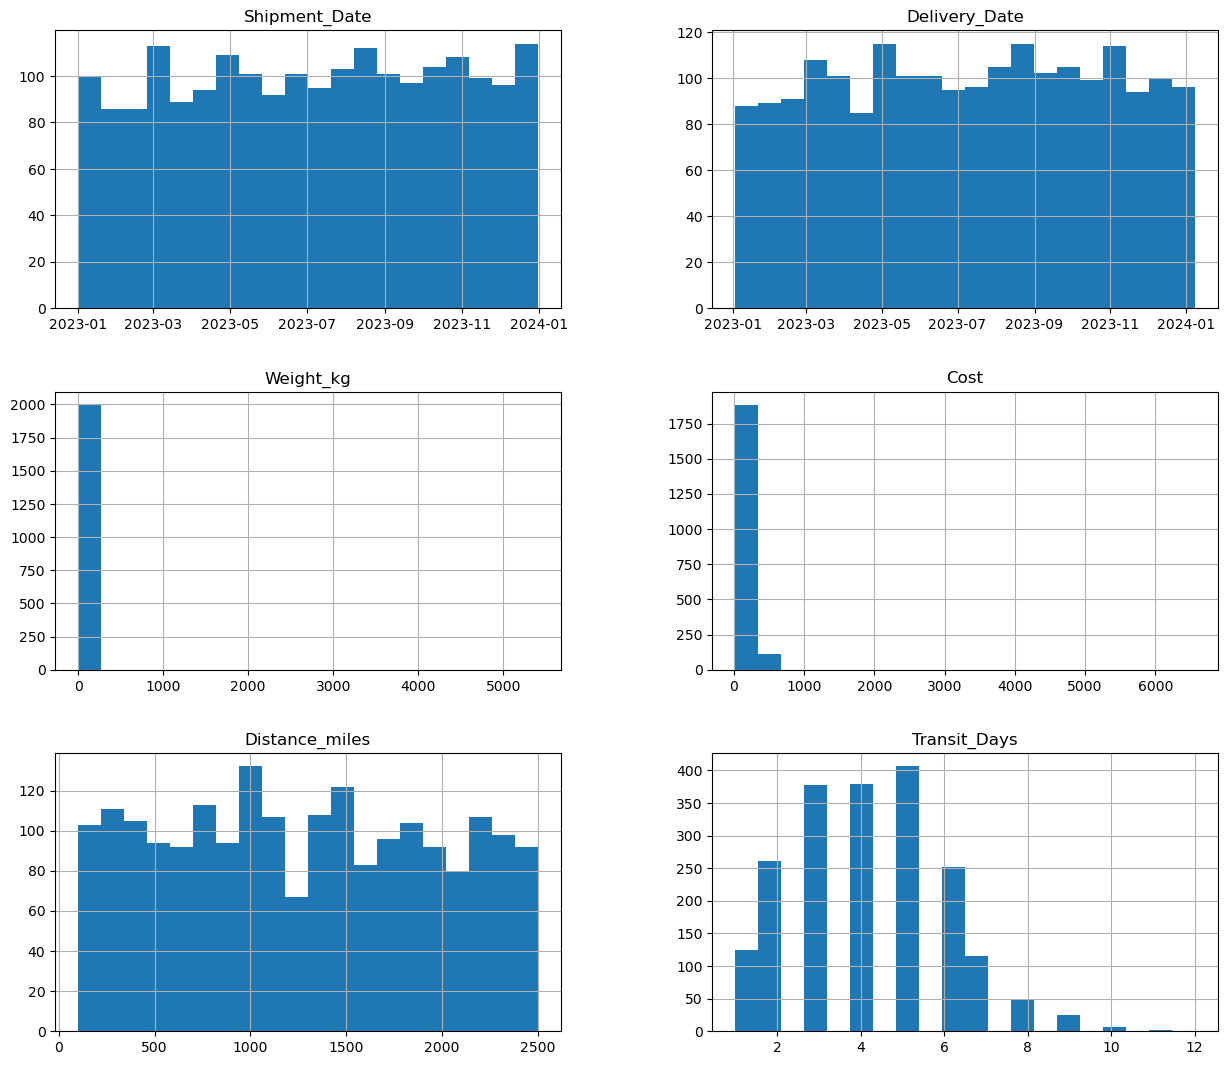

In [4288]:
df.hist(figsize=(15,13), bins =20)
plt.show()

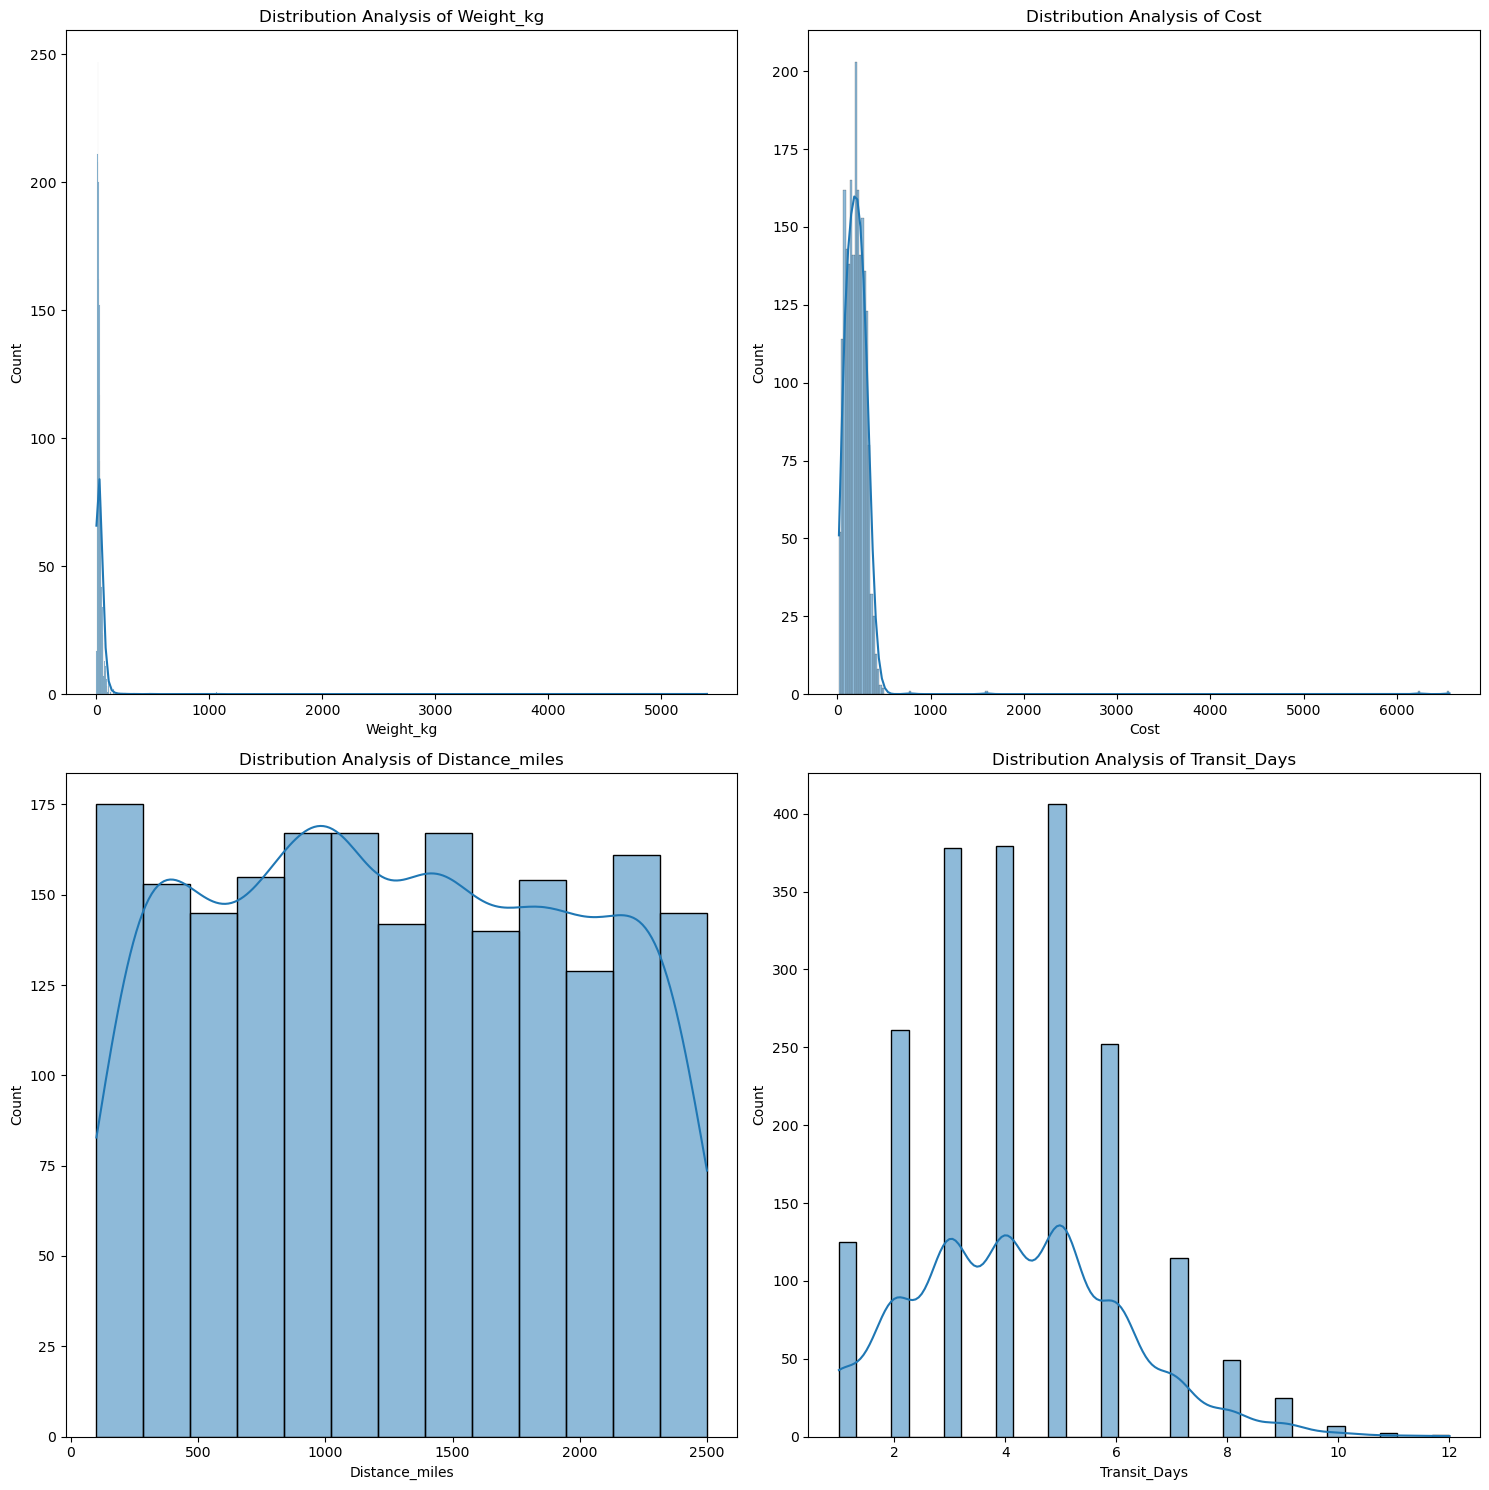

In [4289]:
# Distribution Plot -> only for numerical columns

fig, axes = plt.subplots(2, 2, figsize = (15, 15))
axes = axes.flatten()

num_col = df.select_dtypes(include =  "number").columns
for i, j in enumerate(num_col):
    sns.histplot(df[j], kde = True, ax = axes[i])
    axes[i].set_title(f"Distribution Analysis of {j}")

plt.tight_layout()
plt.show()


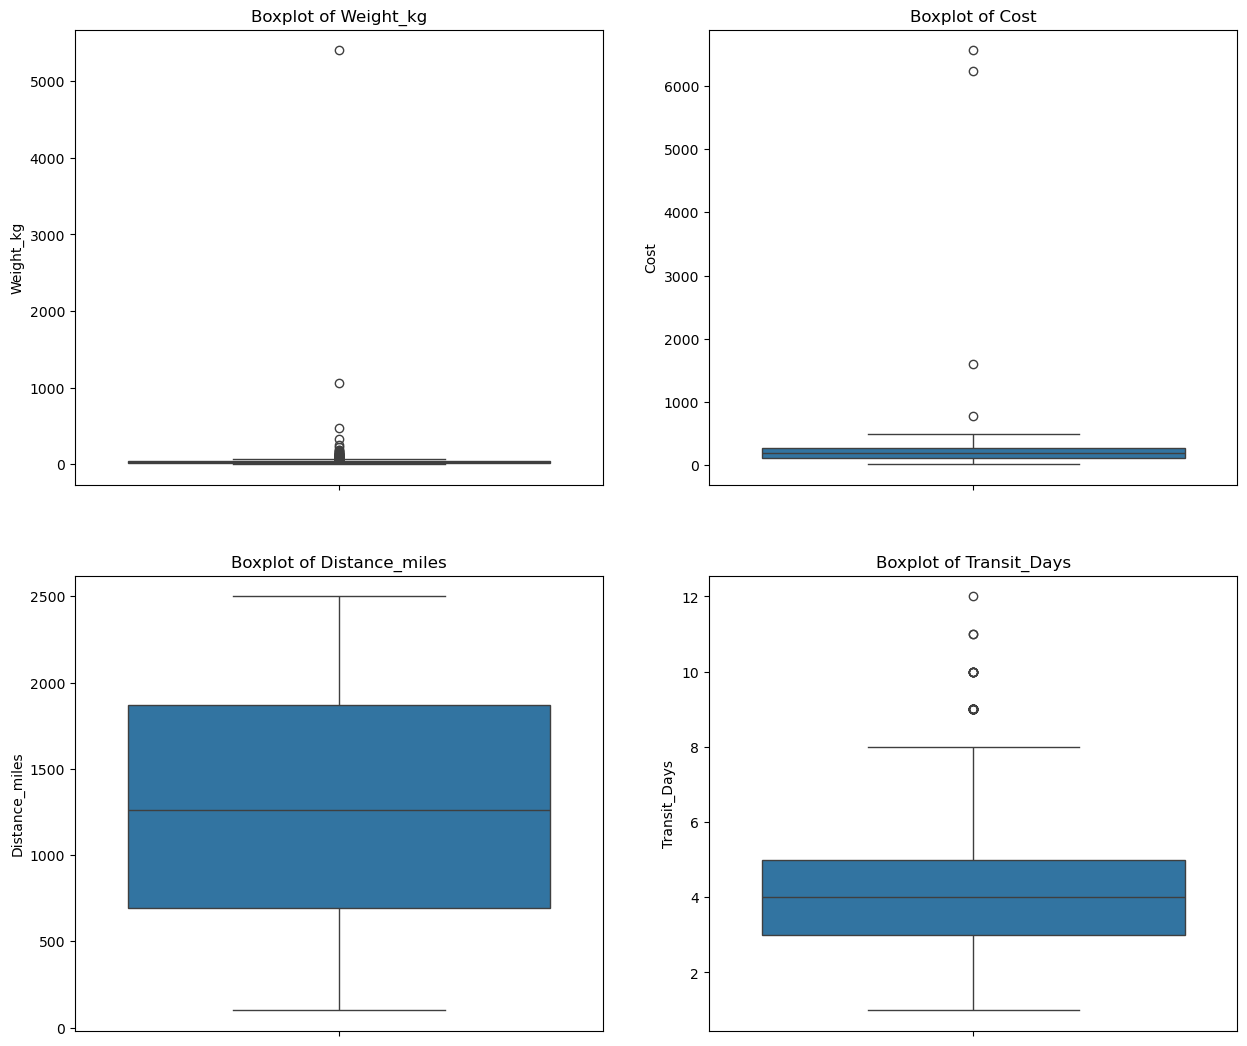

In [4290]:
## Boxplot 
fig, axes = plt.subplots(2,2, figsize = (15, 13))
axes = axes.flatten()

for i, j in enumerate(num_col):
    sns.boxplot(df[j], ax = axes[i])
    axes[i].set_title(f"Boxplot of {j}")

plt.show()

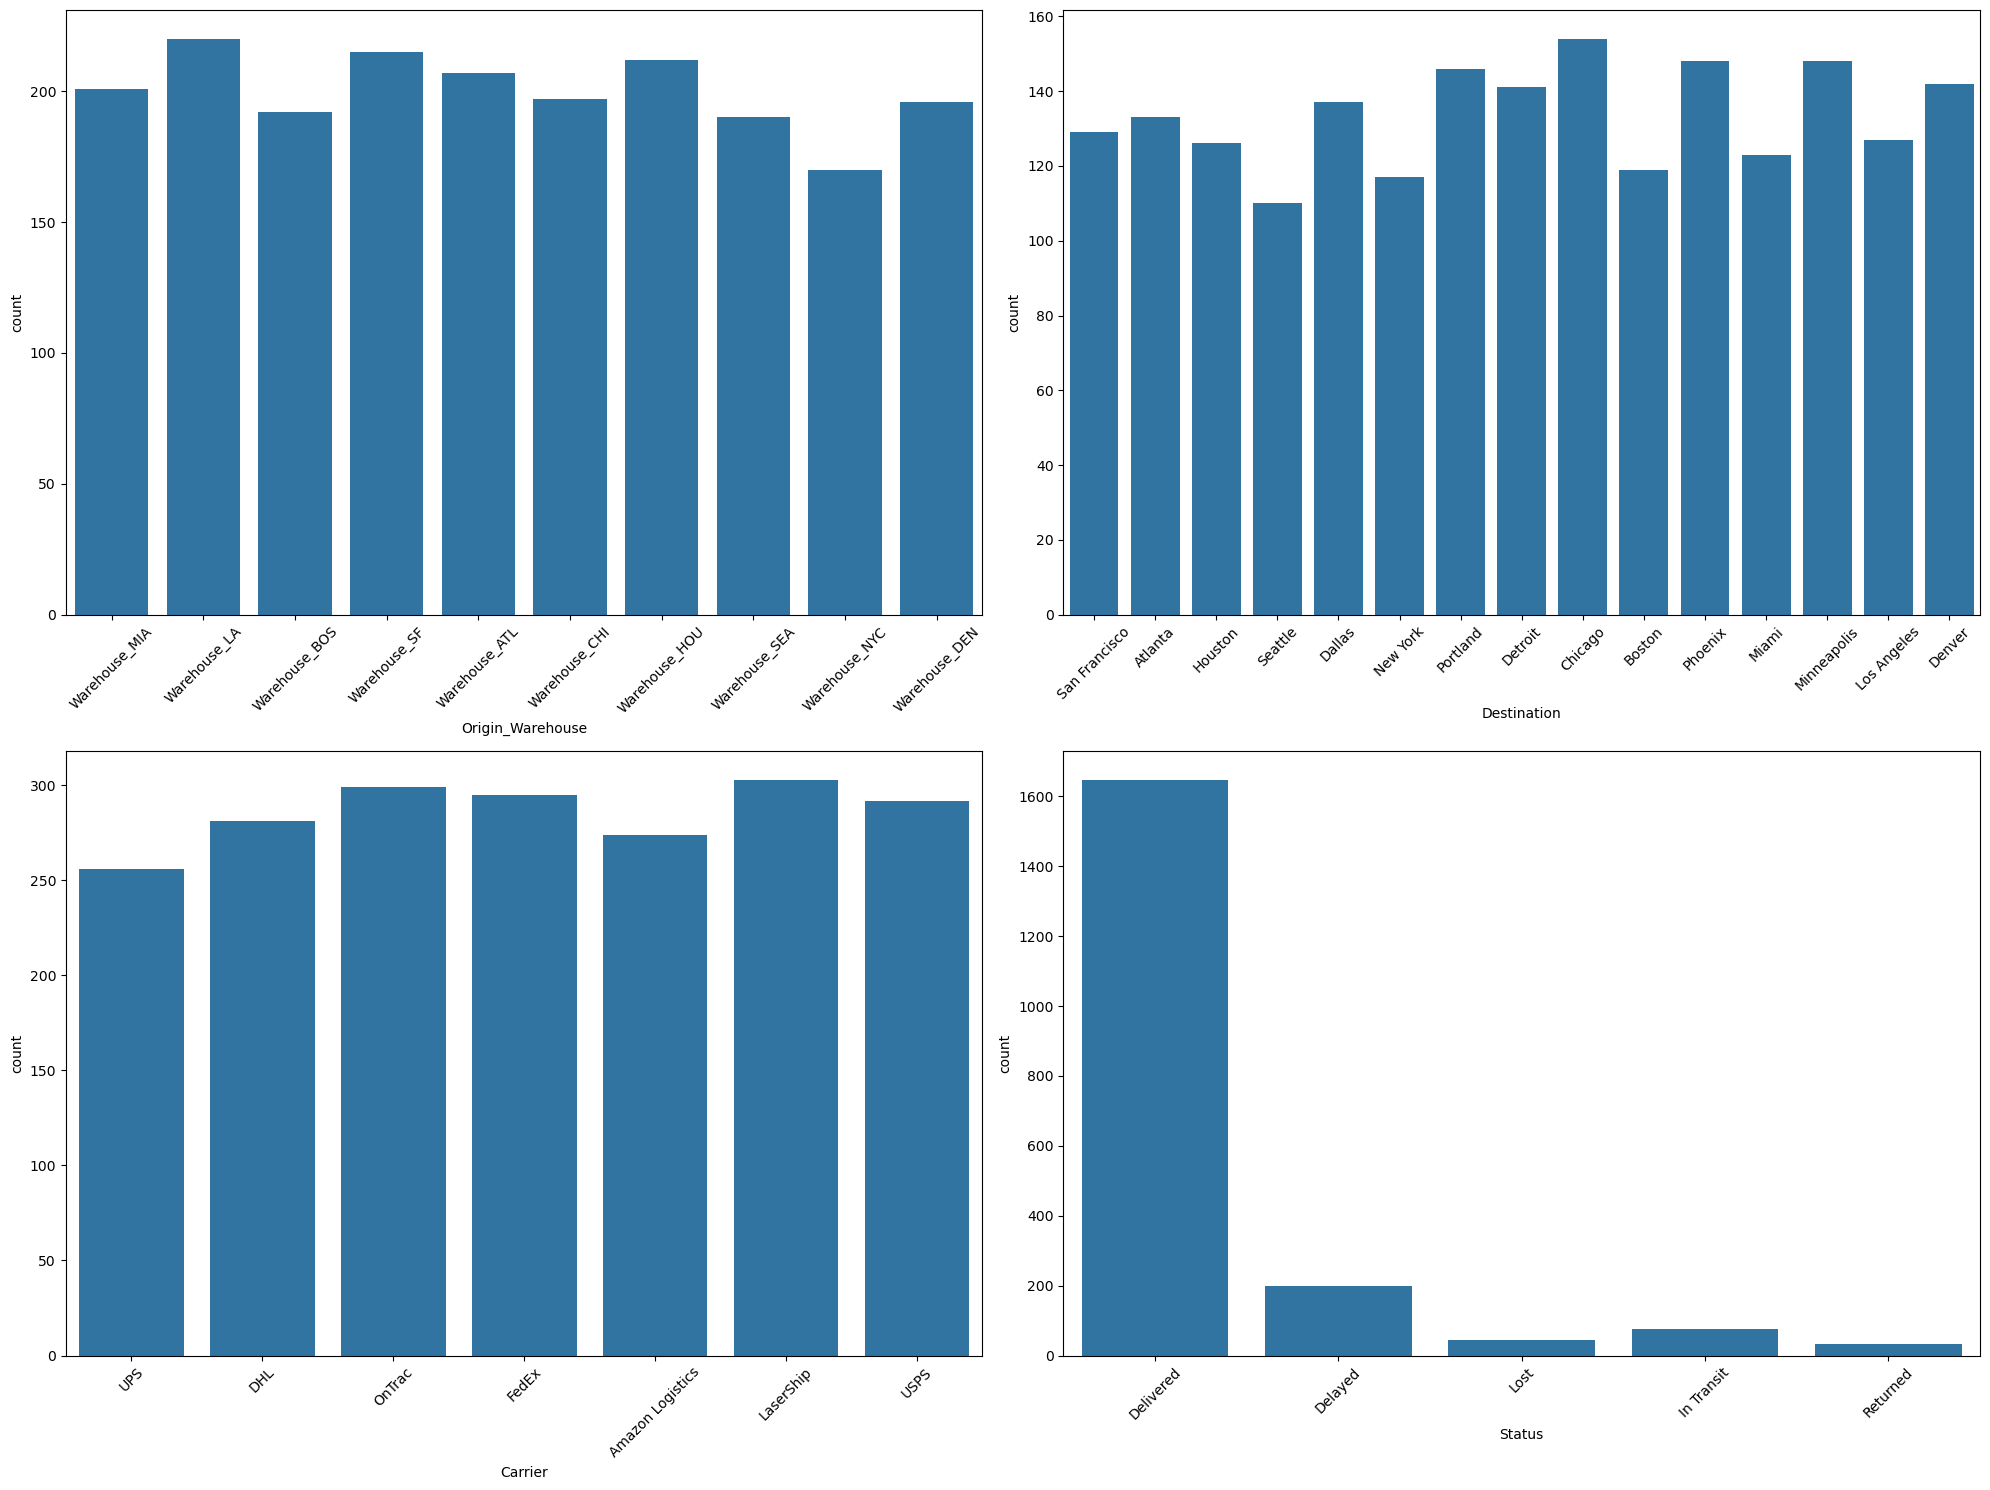

In [4291]:
## Count plot - for categorical variables
fig, axes = plt.subplots(2, 2, figsize = (20, 15))
axes = axes.flatten()

cat_col = df.select_dtypes(include = "object").columns

for i, j in enumerate(cat_col):
    sns.countplot(
        data=df,
        x = j,
        ax = axes[i]
    )
    axes[i].tick_params(axis = 'x', rotation = 45)

plt.tight_layout()

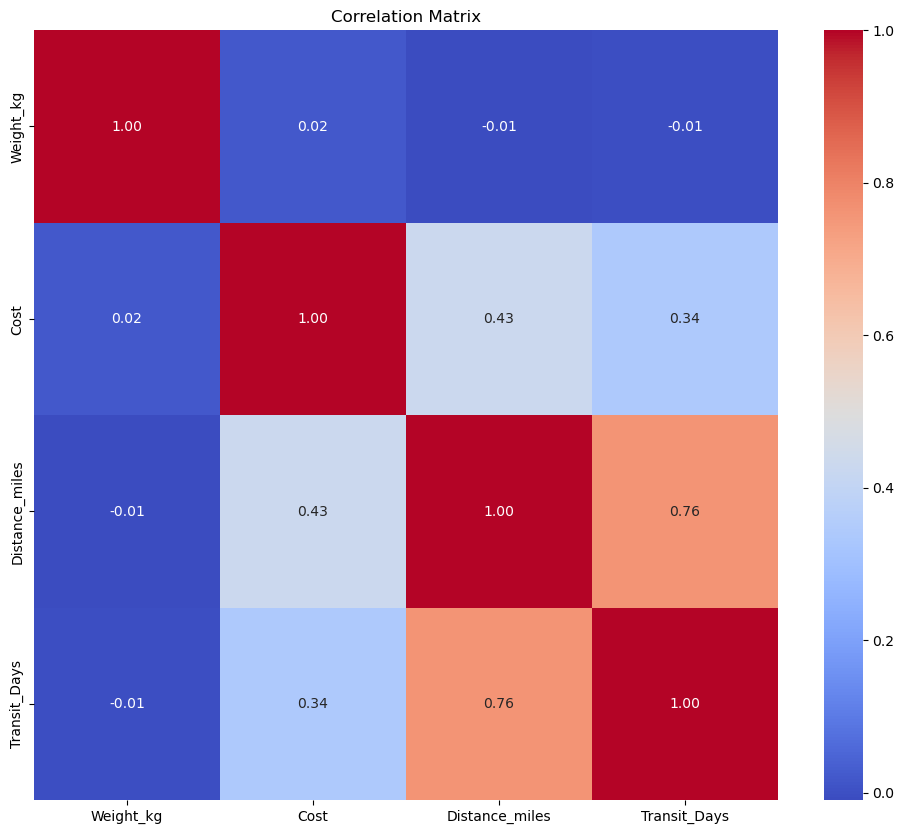

In [4292]:
plt.figure(figsize=(12,10))

corr = df[num_col].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# Hypothesis Testing:

Pearson Correlation -> Numerical Predictors vs Transit Days
One-way ANOVA -> categorical predictor vs Transit Days

## Pearson Correlation

In [4293]:
Numerical_features = [
    "Weight_kg",
    "Cost",
    "Distance_miles"
]

For Each Variable,

Null Hypothesis: There is no linear relationship between the predictor and Transit Days

Alternative Hypothesis: There is linear relationship between the predictor and Transit_Days


In [4294]:
alpha = 0.05
res = []

for col in Numerical_features:
    temp = df[[col, "Transit_Days"]].dropna()

    r, p_value = pearsonr(
        temp[col],
        temp["Transit_Days"]
    )

    res.append({
        "Variable": col,
        "Correlation": r,
        "P-value": p_value,
        "Significant": p_value < alpha
    })

pearson_results = pd.DataFrame(res)

pearson_results

,Variable,Correlation,P-value,Significant
0,Weight_kg,-0.005583,8.029501e-01,False
1,Cost,0.338430,8.806836e-55,True
2,Distance_miles,0.760732,0.000000e+00,True


## Interpretation

#### For Weight_kg, we fail to reject the Null Hypothesis. Hence, there is no evidence of statistically significant linear relationship between shipment weight and transit time

#### For Cost and Distance, we reject the Null Hypothesis. Hence, there is evidence of statistically significant linear relationship between the cost and transit time, although the relationship is relatively weak compared with distance

## One-way Anova

In [4295]:
categorical_features = [
    "Origin_Warehouse",
    "Destination",
    "Carrier"
]

In [4296]:
res = []
alpha = 0.05

for col in categorical_features:
    groups = [
        group["Transit_Days"].dropna()
        for _, group in df.groupby(col)
    ]

    f_stat, p_value = f_oneway(*groups)

    res.append({
        "Variable": col,
        "F-Statistic": f_stat,
        "P-value": p_value,
        "significant": p_value < alpha 
    })

res = pd.DataFrame(res)

res

,Variable,F-Statistic,P-value,significant
0,Origin_Warehouse,1.471042,0.152957,False
1,Destination,1.375347,0.156715,False
2,Carrier,1.235868,0.284683,False


## Interpretation 

#### We fail to reject the Null Hypothesis for all categorical variables, given that we have no evidence of a stastically significant relationship between any of these variables and Transit Time

## Feature Engineering

In [4297]:
df["Shipment_Date"] = pd.to_datetime(df["Shipment_Date"])

df["Shipment_Month"] = df["Shipment_Date"].dt.month

df["Shipment_DayOfWeek"] = df["Shipment_Date"].dt.dayofweek

df["Shipment_Week"] = df["Shipment_Date"].dt.isocalendar().week.astype(int)

df["Shipment_Quarter"] = df["Shipment_Date"].dt.quarter

df["Shipment_Weekend"] = (
    df["Shipment_DayOfWeek"] >= 5
).astype(int)

In [4298]:
# For weather 
df["Shipment_Date"].min(), df["Shipment_Date"].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2023-12-31 00:00:00'))

In [4299]:
# For weather
df["Origin_Warehouse"].unique()

array(['Warehouse_MIA', 'Warehouse_LA', 'Warehouse_BOS', 'Warehouse_SF',
       'Warehouse_ATL', 'Warehouse_CHI', 'Warehouse_HOU', 'Warehouse_SEA',
       'Warehouse_NYC', 'Warehouse_DEN'], dtype=object)

In [4300]:
df["Destination"].unique()

array(['San Francisco', 'Atlanta', 'Houston', 'Seattle', 'Dallas',
       'New York', 'Portland', 'Detroit', 'Chicago', 'Boston', 'Phoenix',
       'Miami', 'Minneapolis', 'Los Angeles', 'Denver'], dtype=object)

In [4301]:
df["Route"] = (
    df["Origin_Warehouse"]
    + "_"
    + df["Destination"]
)

In [4302]:
df["Transit_Days"].describe()

count    2000.000000
mean        4.182500
std         1.837902
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        12.000000
Name: Transit_Days, dtype: float64

In [4303]:
df['Distance_miles'].describe()

count    2000.000000
mean     1275.868000
std       691.382829
min       101.000000
25%       690.250000
50%      1262.500000
75%      1867.250000
max      2499.000000
Name: Distance_miles, dtype: float64

In [4304]:
df["Distance_Group"] = pd.qcut(
    df["Distance_miles"],
    q=4,
    labels=[
        "Very Short",
        "Short",
        "Long",
        "Very Long"
    ]
)

In [4305]:
df["Weight_Group"] = pd.qcut(
    df["Weight_kg"],
    q=4,
    labels=[
        "Light",
        "Medium",
        "Heavy",
        "Very Heavy"
    ]
)

In [4306]:
df["Cost_per_Mile"] = (
    df["Cost"] /
    df["Distance_miles"]
)

df["Weight_per_Mile"] = (
    df["Weight_kg"] /
    df["Distance_miles"]
)

In [4307]:
df.groupby("Distance_Group", observed=True)["Distance_miles"].agg(
    ["min", "max", "mean", "count"]
)

,min,max,mean,count
Distance_Group,,,,
Very Short,101,688,383.512,500
Short,691,1262,973.504,500
Long,1263,1867,1561.406,500
Very Long,1868,2499,2185.050,500


In [4308]:
expected_transit = df.groupby(
    "Distance_Group",
    observed=True
)["Transit_Days"].median()

print(expected_transit)

Distance_Group
Very Short    2.0
Short         3.0
Long          4.0
Very Long     6.0
Name: Transit_Days, dtype: float64


In [4309]:
df['Expected_Transit_Days'] = df['Distance_Group'].map(expected_transit)

# making it numeric
df["Expected_Transit_Days"] = pd.to_numeric(
    df["Expected_Transit_Days"],
    errors="coerce"
)

In [4310]:
df["Transit_Difference"] = (
    df["Transit_Days"] 
    - df["Expected_Transit_Days"]
)

In [4311]:
median_transit = df["Transit_Days"].median()

print("Median transit time:", median_transit)

Median transit time: 4.0


In [4312]:
df[
    [
        "Distance_miles",
        "Distance_Group",
        "Transit_Days",
        "Expected_Transit_Days",
        "Transit_Difference"
    ]
].head(20)

,Distance_miles,Distance_Group,Transit_Days,Expected_Transit_Days,Transit_Difference
Shipment_ID,,,,,
SH10000,291,Very Short,2,2.0,0.0
SH10001,1225,Short,3,3.0,0.0
SH10002,220,Very Short,2,2.0,0.0
SH10003,1156,Short,9,3.0,6.0
SH10004,1017,Short,3,3.0,0.0
SH10005,898,Short,3,3.0,0.0
SH10006,1522,Long,4,4.0,0.0
SH10007,2013,Very Long,9,6.0,3.0
SH10008,2072,Very Long,7,6.0,1.0


In [4313]:
threshold = df['Transit_Difference'].quantile(0.65)

# 0 = Fast, 1 = Slow
df["Slow_Delivery"] = (
    df["Transit_Difference"] >= threshold
).astype(int)

# making sure the classes are not severely imbalanced
df["Slow_Delivery"].value_counts(normalize=True)

Slow_Delivery
0    0.608
1    0.392
Name: proportion, dtype: float64

# Weather Data 

In [4314]:
# coordinates of every Origin Warehouse

warehouse_coords = {
    "Warehouse_MIA": (25.7617, -80.1918),   # Miami
    "Warehouse_LA":  (34.0522, -118.2437),  # Los Angeles
    "Warehouse_BOS": (42.3601, -71.0589),   # Boston
    "Warehouse_SF":  (37.7749, -122.4194),  # San Francisco
    "Warehouse_ATL": (33.7490, -84.3880),   # Atlanta
    "Warehouse_CHI": (41.8781, -87.6298),   # Chicago
    "Warehouse_HOU": (29.7604, -95.3698),   # Houston
    "Warehouse_SEA": (47.6062, -122.3321),  # Seattle
    "Warehouse_NYC": (40.7128, -74.0060),   # New York
    "Warehouse_DEN": (39.7392, -104.9903)   # Denver
}

In [4315]:
def get_historical_weather(latitude, longitude):
    
    url = "https://archive-api.open-meteo.com/v1/archive"
    
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": "2023-01-01",
        "end_date": "2023-12-31",
        "daily": [
            "temperature_2m_mean",
            "precipitation_sum",
            "rain_sum",
            "wind_speed_10m_max"
        ],
        "timezone": "auto"
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    
    data = response.json()["daily"]
    
    weather_df = pd.DataFrame(data)
    
    return weather_df

In [4316]:
all_weather = []

for warehouse, (lat, lon) in warehouse_coords.items():
    print(f"Getting weather for {warehouse}...")
    weather = get_historical_weather(lat, lon)
    
    weather["Origin_Warehouse"] = warehouse
    
    weather["Shipment_Date"] = pd.to_datetime(
        weather["time"]
    )
    
    weather = weather.drop(columns=["time"])
    
    all_weather.append(weather)
    
    time.sleep(1)

Getting weather for Warehouse_MIA...
Getting weather for Warehouse_LA...
Getting weather for Warehouse_BOS...
Getting weather for Warehouse_SF...
Getting weather for Warehouse_ATL...
Getting weather for Warehouse_CHI...
Getting weather for Warehouse_HOU...
Getting weather for Warehouse_SEA...
Getting weather for Warehouse_NYC...
Getting weather for Warehouse_DEN...


In [4317]:
weather_df = pd.concat(
    all_weather,
    ignore_index=True
)

weather_df

,temperature_2m_mean,precipitation_sum,rain_sum,wind_speed_10m_max,Origin_Warehouse,Shipment_Date
0,23.9,1.1,1.1,12.3,Warehouse_MIA,2023-01-01
1,24.1,0.0,0.0,17.2,Warehouse_MIA,2023-01-02
2,24.5,3.5,3.5,19.9,Warehouse_MIA,2023-01-03
3,24.6,1.4,1.4,22.3,Warehouse_MIA,2023-01-04
4,24.3,0.3,0.3,17.3,Warehouse_MIA,2023-01-05
...,...,...,...,...,...,...
3645,0.5,0.0,0.0,9.1,Warehouse_DEN,2023-12-27
3646,-2.7,0.0,0.0,10.7,Warehouse_DEN,2023-12-28
3647,-1.9,0.0,0.0,13.2,Warehouse_DEN,2023-12-29
3648,-0.3,0.0,0.0,12.0,Warehouse_DEN,2023-12-30


In [4318]:
weather_df = weather_df.rename(columns={
    "temperature_2m_mean": "Origin_Temperature",
    "precipitation_sum" : "Origin_Precipitation",
    "rain_sum" : "Origin_Rain",
    "wind_speed_10m_max" : "Origin_Wind"
})

weather_df.head()

,Origin_Temperature,Origin_Precipitation,Origin_Rain,Origin_Wind,Origin_Warehouse,Shipment_Date
0,23.9,1.1,1.1,12.3,Warehouse_MIA,2023-01-01
1,24.1,0.0,0.0,17.2,Warehouse_MIA,2023-01-02
2,24.5,3.5,3.5,19.9,Warehouse_MIA,2023-01-03
3,24.6,1.4,1.4,22.3,Warehouse_MIA,2023-01-04
4,24.3,0.3,0.3,17.3,Warehouse_MIA,2023-01-05


In [4319]:
# merging the weather data and actual df

df = df.merge(
    weather_df,
    on = ['Origin_Warehouse', 'Shipment_Date'],
    how="left"
)

In [4320]:
df

,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days,...,Weight_Group,Cost_per_Mile,Weight_per_Mile,Expected_Transit_Days,Transit_Difference,Slow_Delivery,Origin_Temperature,Origin_Precipitation,Origin_Rain,Origin_Wind
0,Warehouse_MIA,San Francisco,UPS,2023-10-02,2023-10-04,25.7,67.46,Delivered,291,2,...,Heavy,0.231821,0.088316,2.0,0.0,0,26.6,4.0,4.0,31.4
1,Warehouse_MIA,Atlanta,DHL,2023-12-06,2023-12-09,38.9,268.85,Delivered,1225,3,...,Very Heavy,0.219469,0.031755,3.0,0.0,0,17.7,0.0,0.0,21.5
2,Warehouse_LA,Houston,DHL,2023-09-18,2023-09-20,37.2,74.35,Delivered,220,2,...,Very Heavy,0.337955,0.169091,2.0,0.0,0,20.7,0.0,0.0,16.8
3,Warehouse_BOS,Seattle,OnTrac,2023-01-26,2023-02-04,42.6,187.04,Delivered,1156,9,...,Very Heavy,0.161799,0.036851,3.0,6.0,1,7.8,23.0,23.0,37.5
4,Warehouse_SF,Dallas,OnTrac,2023-06-03,2023-06-06,7.9,120.01,Delivered,1017,3,...,Light,0.118004,0.007768,3.0,0.0,0,14.1,0.0,0.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Warehouse_BOS,San Francisco,FedEx,2023-01-18,2023-01-23,7.9,217.78,Delivered,1616,5,...,Light,0.134765,0.004889,4.0,1.0,1,4.6,3.2,3.2,25.2
1996,Warehouse_HOU,Phoenix,UPS,2023-10-27,2023-11-01,36.5,279.47,Delivered,1708,5,...,Very Heavy,0.163624,0.021370,4.0,1.0,1,25.5,2.6,2.6,17.4
1997,Warehouse_HOU,Portland,LaserShip,2023-02-13,2023-02-19,11.4,250.32,Delivered,1912,6,...,Light,0.130921,0.005962,6.0,0.0,0,13.3,0.0,0.0,17.5
1998,Warehouse_SEA,Detroit,USPS,2023-10-17,2023-10-22,10.9,272.31,Delivered,2188,5,...,Light,0.124456,0.004982,6.0,-1.0,0,12.3,2.1,2.1,19.1


In [4321]:
# destination coordinates

destination_coords = {
    "San Francisco": (37.7749, -122.4194),
    "Atlanta": (33.7490, -84.3880),
    "Houston": (29.7604, -95.3698),
    "Seattle": (47.6062, -122.3321),
    "Dallas": (32.7767, -96.7970),
    "New York": (40.7128, -74.0060),
    "Portland": (45.5152, -122.6784),
    "Detroit": (42.3314, -83.0458),
    "Chicago": (41.8781, -87.6298),
    "Boston": (42.3601, -71.0589),
    "Phoenix": (33.4484, -112.0740),
    "Miami": (25.7617, -80.1918),
    "Minneapolis": (44.9778, -93.2650),
    "Los Angeles": (34.0522, -118.2437),
    "Denver": (39.7392, -104.9903)
}

In [4322]:
all_destination_weather = []

for destination, (lat, lon) in destination_coords.items():

    print(f"Getting weather for {destination}...")

    weather = get_historical_weather(lat, lon)

    weather["Destination"] = destination

    weather["Shipment_Date"] = pd.to_datetime(
        weather["time"]
    )

    weather = weather.drop(columns=["time"])

    all_destination_weather.append(weather)

    time.sleep(1)

Getting weather for San Francisco...
Getting weather for Atlanta...
Getting weather for Houston...
Getting weather for Seattle...
Getting weather for Dallas...
Getting weather for New York...
Getting weather for Portland...
Getting weather for Detroit...
Getting weather for Chicago...
Getting weather for Boston...
Getting weather for Phoenix...
Getting weather for Miami...
Getting weather for Minneapolis...
Getting weather for Los Angeles...
Getting weather for Denver...


In [4323]:
destination_weather_df = pd.concat(
    all_destination_weather,
    ignore_index=True
)

In [4324]:
destination_weather_df = destination_weather_df.rename(columns={
    "temperature_2m_mean": "Destination_Temperature",
    "precipitation_sum": "Destination_Precipitation",
    "rain_sum": "Destination_Rain",
    "wind_speed_10m_max": "Destination_Wind"
})

In [4325]:
df = df.merge(
    destination_weather_df,
    on=["Destination", "Shipment_Date"],
    how="left"
)

In [4326]:
# Adding Weather Related Features

df["Rain_Difference"] = (
    df["Destination_Rain"] - df["Origin_Rain"]
)

df["Wind_Difference"] = (
    df["Destination_Wind"] - df["Origin_Wind"]
)

# Heavy Rain
df["Origin_Heavy_Rain"] = (
    df["Origin_Rain"] > 10
).astype(int)

df["Destination_Heavy_Rain"] = (
    df["Destination_Rain"] > 10
).astype(int)

# High Wind
df["Origin_High_Wind"] = (
    df["Origin_Wind"] > 40
).astype(int)

df["Destination_High_Wind"] = (
    df["Destination_Wind"] > 40
).astype(int)

df["Weather_Risk"] = (
    df["Origin_Heavy_Rain"]
    + df["Destination_Heavy_Rain"]
    + df["Origin_High_Wind"]
    + df["Destination_High_Wind"]
)

In [4327]:
weather_df = weather_df.rename(
    columns={"Shipment_Date": "Weather_Date"}
)

destination_weather_df = destination_weather_df.rename(
    columns={"Shipment_Date": "Weather_Date"}
)

df["Shipment_ID"] = df.index


In [4328]:
transit_dates = []

for _, row in df.iterrows():

    dates = pd.date_range(
        start=row["Shipment_Date"],
        end=row["Delivery_Date"],
        freq="D"
    )

    for date in dates:

        transit_dates.append({
            "Shipment_ID": row["Shipment_ID"],
            "Weather_Date": date,
            "Origin_Warehouse": row["Origin_Warehouse"],
            "Destination": row["Destination"]
        })

transit_dates = pd.DataFrame(transit_dates)

In [4329]:
transit_weather = transit_dates.merge(
    weather_df,
    on=["Origin_Warehouse", "Weather_Date"],
    how="left"
)

transit_weather = transit_weather.merge(
    destination_weather_df,
    on=["Destination", "Weather_Date"],
    how="left"
)

max_weather = transit_weather.groupby("Shipment_ID").agg({
    "Origin_Rain": "max",
    "Destination_Rain": "max",
    "Origin_Wind": "max",
    "Destination_Wind": "max"
}).reset_index()


rain_days = transit_weather.groupby("Shipment_ID").agg(
    Origin_Rainy_Days=(
        "Origin_Rain",
        lambda x: (x > 1).sum()
    ),
    Destination_Rainy_Days=(
        "Destination_Rain",
        lambda x: (x > 1).sum()
    )
).reset_index()

wind_days = transit_weather.groupby("Shipment_ID").agg(
    Origin_High_Wind_Days=(
        "Origin_Wind",
        lambda x: (x > 40).sum()
    ),
    Destination_High_Wind_Days=(
        "Destination_Wind",
        lambda x: (x > 40).sum()
    )
).reset_index()


transit_weather_features = (
    max_weather
    .merge(rain_days, on="Shipment_ID")
    .merge(wind_days, on="Shipment_ID")
)


df = df.merge(
    transit_weather_features,
    on="Shipment_ID",
    how="left"
)

## Model 

In [4330]:
# The information the model gets
features = [
    "Origin_Warehouse",
    "Destination",
    "Carrier",
    "Weight_kg",
    "Cost",
    "Distance_miles",
    "Shipment_Month",
    "Shipment_DayOfWeek",
    "Shipment_Week",
    "Shipment_Quarter",
    "Shipment_Weekend",
    "Route",
    "Distance_Group",
    "Weight_Group",
    "Cost_per_Mile",
    "Weight_per_Mile"
]

weather_features = [
    "Weather_Risk",
    "Origin_Rain_y",
    "Destination_Rain_y",
    "Destination_Rainy_Days"
]

all_features = features + weather_features

X = df[all_features]
y = df["Slow_Delivery"]

df

,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days,...,Weather_Risk,Shipment_ID,Origin_Rain_y,Destination_Rain_y,Origin_Wind_y,Destination_Wind_y,Origin_Rainy_Days,Destination_Rainy_Days,Origin_High_Wind_Days,Destination_High_Wind_Days
0,Warehouse_MIA,San Francisco,UPS,2023-10-02,2023-10-04,25.7,67.46,Delivered,291,2,...,0,0,4.0,0.0,31.4,23.8,2,0,0,0
1,Warehouse_MIA,Atlanta,DHL,2023-12-06,2023-12-09,38.9,268.85,Delivered,1225,3,...,0,1,0.1,4.1,24.7,24.4,0,1,0,0
2,Warehouse_LA,Houston,DHL,2023-09-18,2023-09-20,37.2,74.35,Delivered,220,2,...,0,2,0.0,0.0,19.6,20.0,0,0,0,0
3,Warehouse_BOS,Seattle,OnTrac,2023-01-26,2023-02-04,42.6,187.04,Delivered,1156,9,...,1,3,23.0,4.6,37.8,33.8,1,4,0,0
4,Warehouse_SF,Dallas,OnTrac,2023-06-03,2023-06-06,7.9,120.01,Delivered,1017,3,...,1,4,0.3,22.4,35.9,23.0,0,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Warehouse_BOS,San Francisco,FedEx,2023-01-18,2023-01-23,7.9,217.78,Delivered,1616,5,...,0,1995,20.6,2.1,25.3,30.4,5,2,0,0
1996,Warehouse_HOU,Phoenix,UPS,2023-10-27,2023-11-01,36.5,279.47,Delivered,1708,5,...,0,1996,5.5,0.0,31.9,26.6,4,0,0,0
1997,Warehouse_HOU,Portland,LaserShip,2023-02-13,2023-02-19,11.4,250.32,Delivered,1912,6,...,1,1997,3.9,11.5,32.2,19.6,3,1,0,0
1998,Warehouse_SEA,Detroit,USPS,2023-10-17,2023-10-22,10.9,272.31,Delivered,2188,5,...,0,1998,2.1,6.1,19.1,25.3,1,2,0,0


In [4331]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX:")
print(X.head())

print("\ny:")
print(y.head())

X shape: (2000, 20)
y shape: (2000,)

X:
  Origin_Warehouse    Destination Carrier  Weight_kg    Cost  Distance_miles  \
0    Warehouse_MIA  San Francisco     UPS       25.7   67.46             291   
1    Warehouse_MIA        Atlanta     DHL       38.9  268.85            1225   
2     Warehouse_LA        Houston     DHL       37.2   74.35             220   
3    Warehouse_BOS        Seattle  OnTrac       42.6  187.04            1156   
4     Warehouse_SF         Dallas  OnTrac        7.9  120.01            1017   

   Shipment_Month  Shipment_DayOfWeek  Shipment_Week  Shipment_Quarter  \
0              10                   0             40                 4   
1              12                   2             49                 4   
2               9                   0             38                 3   
3               1                   3              4                 1   
4               6                   5             22                 2   

   Shipment_Weekend              

In [4332]:
# categorical features have been defined above

X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

In [4333]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4334]:
print("Training:", y_train.value_counts())
print("Testing:", y_test.value_counts())

Training: Slow_Delivery
0    973
1    627
Name: count, dtype: int64
Testing: Slow_Delivery
0    243
1    157
Name: count, dtype: int64


In [4335]:
# numerical features have been defined above
scaler = StandardScaler()

X_train[Numerical_features] = scaler.fit_transform(
    X_train[Numerical_features]
)

X_test[Numerical_features] = scaler.transform(
    X_test[Numerical_features]
)

In [4336]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]


In [4337]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
classification_report_x = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print(classification_report_x)


Confusion Matrix:
[[196  47]
 [ 97  60]]
              precision    recall  f1-score   support

           0       0.67      0.81      0.73       243
           1       0.56      0.38      0.45       157

    accuracy                           0.64       400
   macro avg       0.61      0.59      0.59       400
weighted avg       0.63      0.64      0.62       400



In [4338]:
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC: ", auc)

ROC-AUC:  0.6296558412623522


In [4339]:
print("Features used by model")
print(X.columns.tolist())

Features used by model
['Weight_kg', 'Cost', 'Distance_miles', 'Shipment_Month', 'Shipment_DayOfWeek', 'Shipment_Week', 'Shipment_Quarter', 'Shipment_Weekend', 'Cost_per_Mile', 'Weight_per_Mile', 'Weather_Risk', 'Origin_Rain_y', 'Destination_Rain_y', 'Destination_Rainy_Days', 'Origin_Warehouse_Warehouse_BOS', 'Origin_Warehouse_Warehouse_CHI', 'Origin_Warehouse_Warehouse_DEN', 'Origin_Warehouse_Warehouse_HOU', 'Origin_Warehouse_Warehouse_LA', 'Origin_Warehouse_Warehouse_MIA', 'Origin_Warehouse_Warehouse_NYC', 'Origin_Warehouse_Warehouse_SEA', 'Origin_Warehouse_Warehouse_SF', 'Destination_Boston', 'Destination_Chicago', 'Destination_Dallas', 'Destination_Denver', 'Destination_Detroit', 'Destination_Houston', 'Destination_Los Angeles', 'Destination_Miami', 'Destination_Minneapolis', 'Destination_New York', 'Destination_Phoenix', 'Destination_Portland', 'Destination_San Francisco', 'Destination_Seattle', 'Carrier_DHL', 'Carrier_FedEx', 'Carrier_LaserShip', 'Carrier_OnTrac', 'Carrier_UPS', 

Since, the AUC for both falls between 0.51 and 
0.60, the dataset does not have enough information to predict unexpected delays

#### Next step: Feature engineering shipment features and route




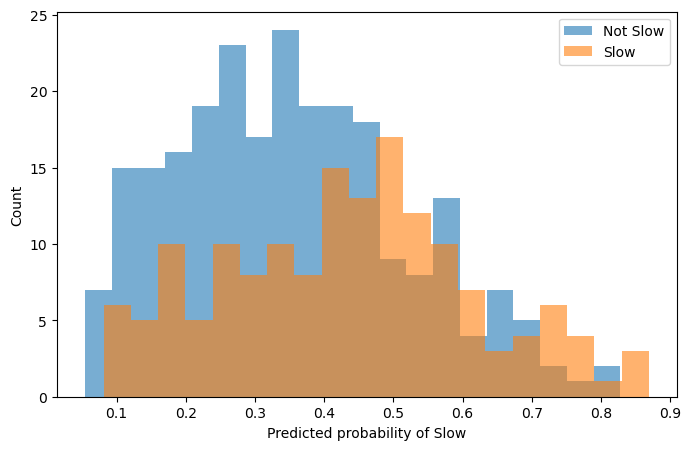

In [4340]:
# does tuning the threshold help? given that at 0.60 threshold, we have the model giving recall 0.08 for fast deliveries
# and threshold at 0.80, gets a recall for 1 at 0.35 

y_prob = logistic_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8,5))

plt.hist(
    y_prob[y_test == 0],
    bins=20,
    alpha=0.6,
    label="Not Slow"
)

plt.hist(
    y_prob[y_test == 1],
    bins=20,
    alpha=0.6,
    label="Slow"
)

plt.xlabel("Predicted probability of Slow")
plt.ylabel("Count")
plt.legend()
plt.show()

### Slow Delivery Classification

The objective of this model was to predict whether a shipment would be classified as **Slow Delivery**, where a shipment was considered slow if its actual transit time exceeded the expected transit time for its route. After completing exploratory data analysis (EDA) and hypothesis testing, additional features were engineered, including shipment date components, route information, and operational variables. Logistic Regression and Random Forest classifiers were then trained and evaluated.

Although feature engineering improved the model compared with the initial baseline, overall performance remained modest. The best model achieved a ROC-AUC of approximately **0.60**, indicating only limited ability to distinguish between slow and on-time deliveries. Adjusting the classification threshold changed the balance between precision and recall but did not substantially improve the model, suggesting that the limitation stemmed from the available data rather than the decision threshold.

The results indicate that unexpected shipment delays are influenced by factors that are not included in the dataset, such as weather conditions, traffic congestion, warehouse workload, vehicle availability, or operational disruptions. Consequently, the available variables were insufficient to accurately predict whether a shipment would be delayed beyond its expected transit time.




try boosting algorithm 
- learn boosting algo first, give this project a few days break and come back afterwards

In [4341]:
X_base = df[features].copy()

X_weather = df[all_features].copy()

y = df["Slow_Delivery"]

In [4342]:
X_base = pd.get_dummies(
    X_base,
    drop_first=True
)

X_weather = pd.get_dummies(
    X_weather,
    drop_first=True
)

In [4343]:
from sklearn.model_selection import train_test_split

X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.2,
    random_state=42,
    #stratify=y
)

In [4344]:
X_weather_train = X_weather.loc[X_base_train.index]
X_weather_test = X_weather.loc[X_base_test.index]

In [4345]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_regression(model_name, y_test, y_pred):
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"MAE:  {mae:.3f} days")
    print(f"RMSE: {rmse:.3f} days")
    print(f"R²:   {r2:.3f}")

In [4346]:
from sklearn.ensemble import GradientBoostingClassifier

gb_base = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_base.fit(
    X_base_train,
    y_train
)

y_pred_base = gb_base.predict(X_base_test)

y_prob_base = gb_base.predict_proba(
    X_base_test
)[:, 1]

In [4347]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Baseline Gradient Boosting")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_base))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_base))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_base)
)

Baseline Gradient Boosting

Confusion Matrix:
[[212  23]
 [130  35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.90      0.73       235
           1       0.60      0.21      0.31       165

    accuracy                           0.62       400
   macro avg       0.61      0.56      0.52       400
weighted avg       0.61      0.62      0.56       400

ROC-AUC: 0.5965441650548033


In [4348]:
gb_weather = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_weather.fit(
    X_weather_train,
    y_train
)

y_pred_weather = gb_weather.predict(
    X_weather_test
)

y_prob_weather = gb_weather.predict_proba(
    X_weather_test
)[:, 1]


print("Gradient Boosting + Weather")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_weather))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_weather))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_weather)
)

Gradient Boosting + Weather

Confusion Matrix:
[[192  43]
 [111  54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.82      0.71       235
           1       0.56      0.33      0.41       165

    accuracy                           0.61       400
   macro avg       0.60      0.57      0.56       400
weighted avg       0.60      0.61      0.59       400

ROC-AUC: 0.6062669245647969


In [4349]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision - Slow",
        "Recall - Slow",
        "F1 - Slow",
        "ROC-AUC"
    ],

    "Gradient Boosting": [
        accuracy_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base),
        roc_auc_score(y_test, y_prob_base)
    ],

    "Gradient Boosting + Weather": [
        accuracy_score(y_test, y_pred_weather),
        precision_score(y_test, y_pred_weather),
        recall_score(y_test, y_pred_weather),
        f1_score(y_test, y_pred_weather),
        roc_auc_score(y_test, y_prob_weather)
    ]
})

results

,Metric,Gradient Boosting,Gradient Boosting + Weather
0,Accuracy,0.617500,0.615000
1,Precision - Slow,0.603448,0.556701
2,Recall - Slow,0.212121,0.327273
3,F1 - Slow,0.313901,0.412214
4,ROC-AUC,0.596544,0.606267


In [4350]:
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier

In [4351]:
xgb_base = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_base.fit(
    X_base_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [4352]:
y_pred_xgb_base = xgb_base.predict(X_base_test)

y_prob_xgb_base = xgb_base.predict_proba(
    X_base_test
)[:, 1]

In [4353]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("XGBoost — Baseline")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_base))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_base))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_xgb_base)
)

XGBoost — Baseline

Confusion Matrix:
[[205  30]
 [130  35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.87      0.72       235
           1       0.54      0.21      0.30       165

    accuracy                           0.60       400
   macro avg       0.58      0.54      0.51       400
weighted avg       0.58      0.60      0.55       400

ROC-AUC: 0.5963894261766602


In [4354]:
xgb_weather = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_weather.fit(
    X_weather_train,
    y_train
)

y_pred_xgb_weather = xgb_weather.predict(
    X_weather_test
)

y_prob_xgb_weather = xgb_weather.predict_proba(
    X_weather_test
)[:, 1]


print("XGBoost — With Weather")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_weather))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_weather))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_xgb_weather)
)



XGBoost — With Weather

Confusion Matrix:
[[187  48]
 [105  60]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.80      0.71       235
           1       0.56      0.36      0.44       165

    accuracy                           0.62       400
   macro avg       0.60      0.58      0.57       400
weighted avg       0.61      0.62      0.60       400

ROC-AUC: 0.6174081237911024


In [4355]:
threshold = 0.45

y_pred_final = (
    y_prob_xgb_weather >= threshold
).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))


Confusion Matrix:
[[165  70]
 [ 90  75]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.70      0.67       235
           1       0.52      0.45      0.48       165

    accuracy                           0.60       400
   macro avg       0.58      0.58      0.58       400
weighted avg       0.59      0.60      0.60       400



In [4360]:
print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_pred_final)
)

ROC-AUC: 0.5783365570599613


In [4357]:
ada_base = AdaBoostClassifier(
    n_estimators=150,
    learning_rate=1,
    random_state=42
)

ada_base.fit(
    X_base_train,
    y_train
)

y_pred_ada_base = ada_base.predict(
    X_base_test
)

y_prob_ada_base = ada_base.predict_proba(
    X_base_test
)[:, 1]


print("AdaBoost — Baseline")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada_base))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada_base))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_ada_base)
)

AdaBoost — Baseline

Confusion Matrix:
[[215  20]
 [141  24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.91      0.73       235
           1       0.55      0.15      0.23       165

    accuracy                           0.60       400
   macro avg       0.57      0.53      0.48       400
weighted avg       0.58      0.60      0.52       400

ROC-AUC: 0.5981560283687943


In [4358]:
ada_weather = AdaBoostClassifier(
    n_estimators=500,
    learning_rate=1,
    random_state=42,
    algorithm = "SAMME"
)

ada_weather.fit(
    X_weather_train,
    y_train
)

y_pred_ada_weather = ada_weather.predict(
    X_weather_test
)

y_prob_ada_weather = ada_weather.predict_proba(
    X_weather_test
)[:, 1]


print("AdaBoost — With Weather")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada_weather))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada_weather))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_ada_weather)
)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost — With Weather

Confusion Matrix:
[[197  38]
 [110  55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.84      0.73       235
           1       0.59      0.33      0.43       165

    accuracy                           0.63       400
   macro avg       0.62      0.59      0.58       400
weighted avg       0.62      0.63      0.60       400

ROC-AUC: 0.6276079948420373


In [4359]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_weather.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

top_15_features = importance.head(15)['Feature'].tolist()
top_15_features

['Distance_Group_Very Long',
 'Destination_Rainy_Days',
 'Distance_miles',
 'Origin_Warehouse_Warehouse_CHI',
 'Distance_Group_Long',
 'Carrier_FedEx',
 'Weight_Group_Very Heavy',
 'Origin_Rain_y',
 'Route_Warehouse_CHI_Miami',
 'Destination_San Francisco',
 'Destination_Denver',
 'Destination_Miami',
 'Route_Warehouse_HOU_Miami',
 'Destination_Rain_y',
 'Destination_New York']